###### Import Libraries and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

In [2]:
deliveries= pd.read_csv(r'C:\Users\SACHIN\Downloads\IPL_dataset\deliveries.csv')
matches = pd.read_csv(r'C:\Users\SACHIN\Downloads\IPL_dataset\matches.csv')

In [3]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
matches.shape

(1095, 20)

In [6]:
deliveries.shape

(260920, 17)

In [7]:
matches['team1'].value_counts()

team1
Royal Challengers Bangalore    135
Chennai Super Kings            128
Mumbai Indians                 123
Kolkata Knight Riders          121
Rajasthan Royals               101
Kings XI Punjab                 92
Sunrisers Hyderabad             86
Delhi Daredevils                85
Delhi Capitals                  41
Deccan Chargers                 39
Punjab Kings                    31
Lucknow Super Giants            23
Pune Warriors                   23
Gujarat Titans                  21
Gujarat Lions                   16
Royal Challengers Bengaluru      9
Kochi Tuskers Kerala             7
Rising Pune Supergiant           7
Rising Pune Supergiants          7
Name: count, dtype: int64

In [8]:
matches['team2'].value_counts()

team2
Mumbai Indians                 138
Kolkata Knight Riders          130
Rajasthan Royals               120
Chennai Super Kings            110
Royal Challengers Bangalore    105
Kings XI Punjab                 98
Sunrisers Hyderabad             96
Delhi Daredevils                76
Delhi Capitals                  50
Deccan Chargers                 36
Punjab Kings                    25
Gujarat Titans                  24
Pune Warriors                   23
Lucknow Super Giants            21
Gujarat Lions                   14
Rising Pune Supergiant           9
Kochi Tuskers Kerala             7
Rising Pune Supergiants          7
Royal Challengers Bengaluru      6
Name: count, dtype: int64

In [9]:
deliveries['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Royal Challengers Bangalore    28205
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          1900
Royal Challengers Bengaluru     1818
Kochi Tuskers Kerala            1582
Rising Pune Supergiants         1580
Name: count, dtype: int64

###### Data Cleaning

In [38]:
matches['team1'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
matches['team2'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
matches['toss_winner'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
matches['winner'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)

In [40]:
matches['team1'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)
matches['team2'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)
matches['toss_winner'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)
matches['winner'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)

In [12]:
matches['team2'].value_counts()

team2
Mumbai Indians                 138
Kolkata Knight Riders          130
Rajasthan Royals               120
Royal Challengers Bangalore    111
Chennai Super Kings            110
Kings XI Punjab                 98
Sunrisers Hyderabad             96
Delhi Daredevils                76
Delhi Capitals                  50
Deccan Chargers                 36
Punjab Kings                    25
Gujarat Titans                  24
Pune Warriors                   23
Lucknow Super Giants            21
Rising Pune Supergiant          16
Gujarat Lions                   14
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [13]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [41]:
deliveries['batting_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)
deliveries['bowling_team'].replace({'Rising Pune Supergiants':'Rising Pune Supergiant'},inplace=True)

deliveries['batting_team'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)
deliveries['bowling_team'].replace({'Royal Challengers Bengaluru':'Royal Challengers Bangalore'},inplace=True)

In [15]:
deliveries['batting_team'].value_counts()

batting_team
Mumbai Indians                 31437
Royal Challengers Bangalore    30023
Kolkata Knight Riders          29514
Chennai Super Kings            28651
Rajasthan Royals               26242
Kings XI Punjab                22646
Sunrisers Hyderabad            21843
Delhi Daredevils               18786
Delhi Capitals                 10946
Deccan Chargers                 9034
Punjab Kings                    6833
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiant          3480
Kochi Tuskers Kerala            1582
Name: count, dtype: int64

In [16]:
matches['city'].isna().sum()

np.int64(51)

In [17]:
matches['method'].value_counts()

method
D/L    21
Name: count, dtype: int64

In [18]:
matches['city'].fillna('Unknown',inplace=True)
matches['method'].fillna('Non D/L',inplace=True)

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_31020\1117966828.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['city'].fillna('Unknown',inplace=True)
C:\Users\SACHIN\AppData\Local\Temp\ipykernel_31020\1117966828.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

###### Success Rate of Teams

In [19]:
def random_colors(no_of_colors):
    return ['#'+''.join([np.random.choice(list('0123456789ABCDEF')) for _ in range(6)]) for _ in range(no_of_colors)]

In [20]:
random_colors(6)

['#8FD21D', '#33D1F7', '#64C4C2', '#714C6C', '#581FB5', '#DFB30F']

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_31020\1010771273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=success_ratio_desc.index,y=success_ratio_desc.values, palette=random_colors(len(success_ratio_desc)))


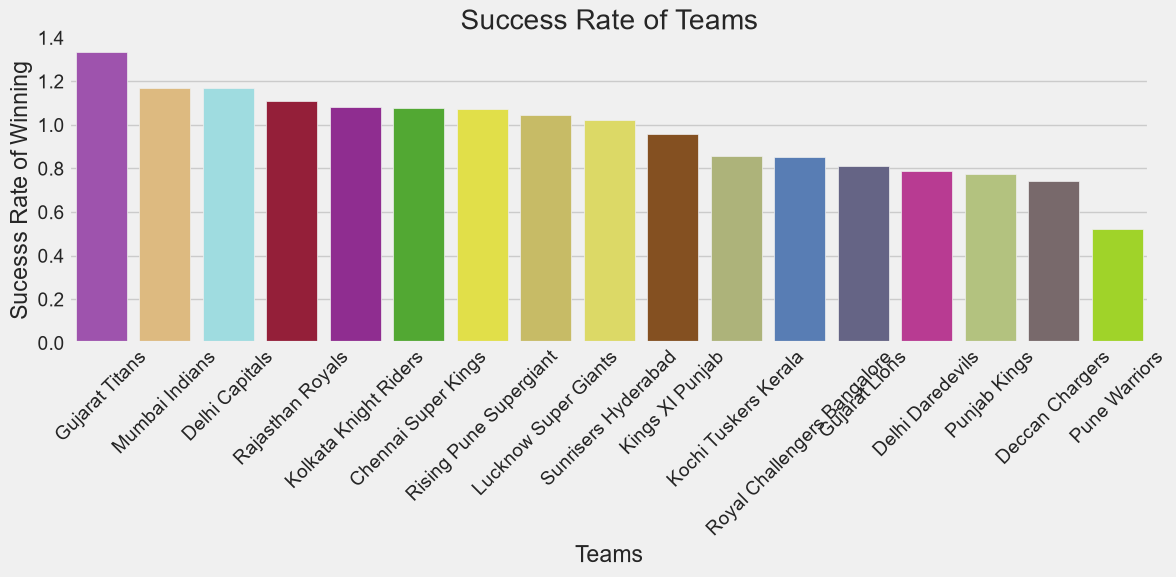

In [21]:
success_ratio = matches.groupby('winner').count()['id']/matches.groupby('team1').count()['id']
success_ratio_desc = success_ratio.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=success_ratio_desc.index,y=success_ratio_desc.values, palette=random_colors(len(success_ratio_desc)))
plt.title('Success Rate of Teams')
plt.xlabel('Teams')
plt.ylabel('Sucesss Rate of Winning')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

###### Most Titles Wins

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_31020\2271284019.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=winner_counts.index,y=winner_counts.values, palette=random_colors(len(winner_counts)))


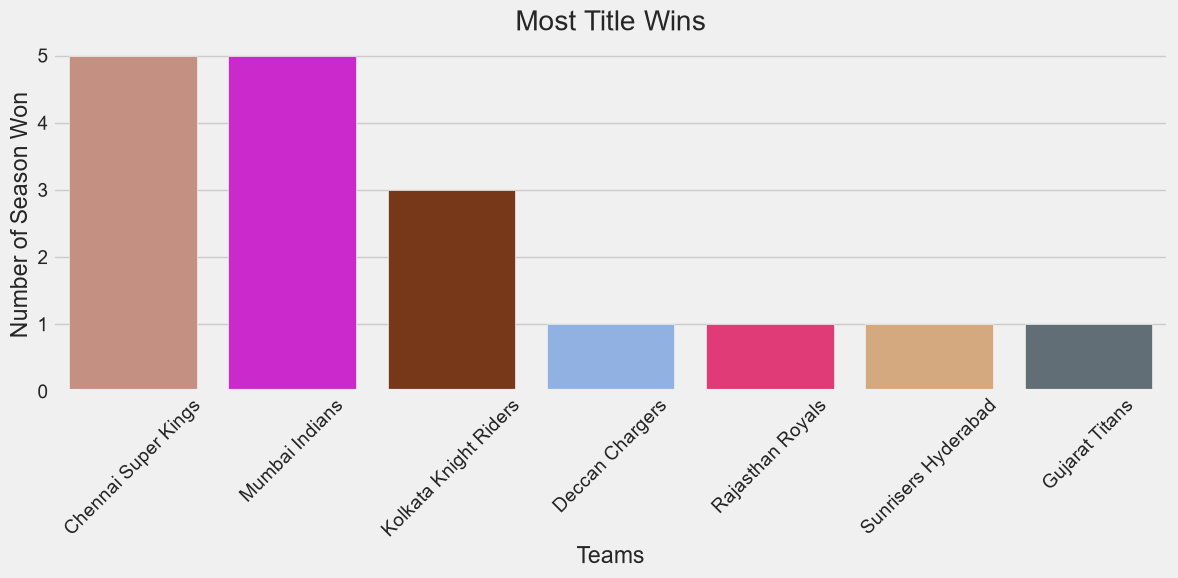

In [22]:
winner_counts = matches.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()


plt.figure(figsize=(12,6))
sns.barplot(x=winner_counts.index,y=winner_counts.values, palette=random_colors(len(winner_counts)))
plt.title('Most Title Wins')
plt.xlabel('Teams')
plt.ylabel('Number of Season Won')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

###### Top 10 Players with Most Runs

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_31020\1374638685.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='batter',y='Runs', data= top_batsmen, palette=random_colors(10))


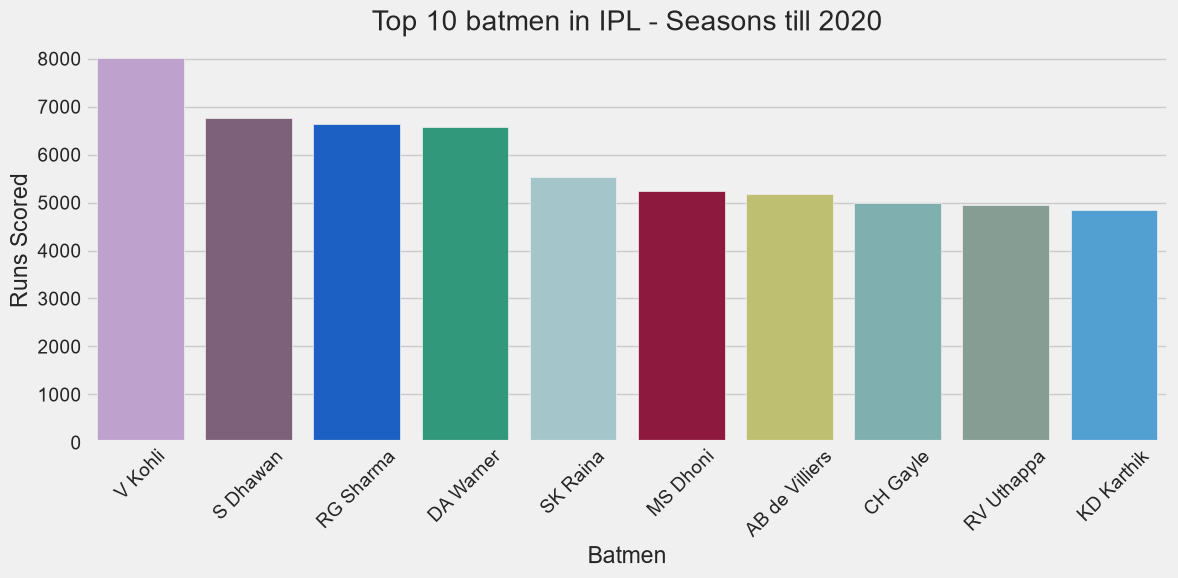

In [23]:
batting_tot = deliveries.groupby('batter')['batsman_runs'].sum().reset_index(name='Runs')
top_batsmen = batting_tot.sort_values(by='Runs',ascending=False)[:10]

plt.figure(figsize=(12,6))
sns.barplot(x='batter',y='Runs', data= top_batsmen, palette=random_colors(10))
plt.title('Top 10 batmen in IPL - Seasons till 2020')
plt.xlabel('Batmen')
plt.ylabel('Runs Scored')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

###### Top 10 Best Performances in a Match

In [24]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN


In [25]:
batting_ings = deliveries.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index(name='Innings Runs')
top_batsmen_scores = batting_ings.sort_values(by='Innings Runs',ascending=False)[:10]

In [26]:
batsman_ball_faced = deliveries.groupby(['match_id', 'batter'])['batsman_runs'].count().reset_index(name='Balls Faced')

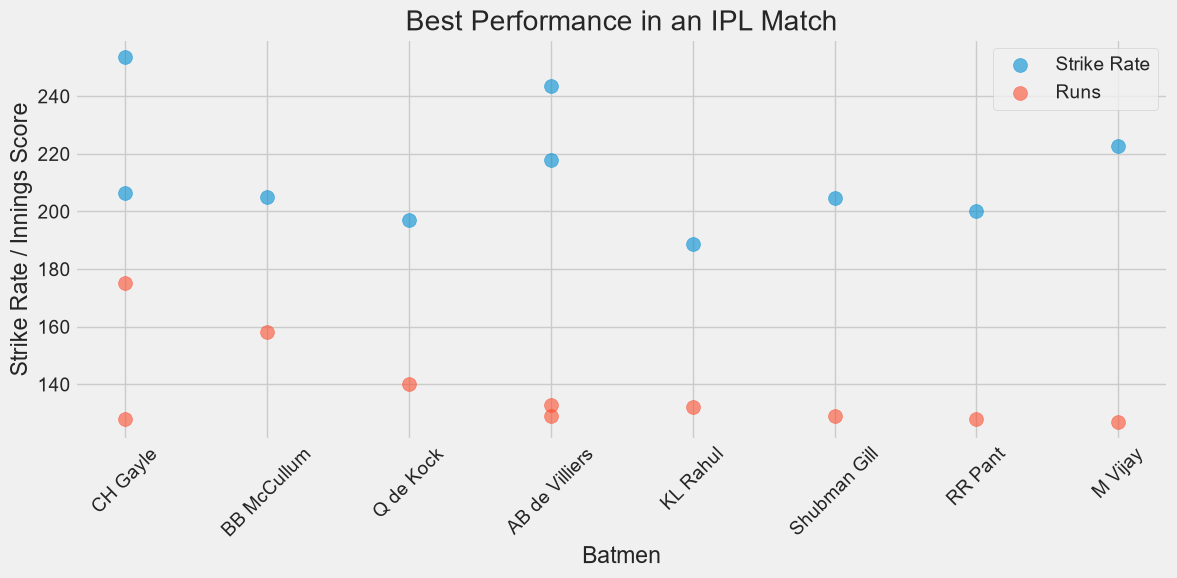

In [27]:
batsmen_performance = pd.merge(top_batsmen_scores,batsman_ball_faced,how='inner', on=['match_id','batter'])
batsmen_performance['Strike Rate for Match'] = np.round(batsmen_performance['Innings Runs']*100/batsmen_performance['Balls Faced'],2)
batsmen_performance

plt.figure(figsize=(12,6))
plt.scatter(batsmen_performance['batter'],batsmen_performance['Strike Rate for Match'], label='Strike Rate',s=100, alpha=0.6)
plt.scatter(batsmen_performance['batter'],batsmen_performance['Innings Runs'], label='Runs',s=100, alpha=0.6)
plt.title('Best Performance in an IPL Match')
plt.xlabel('Batmen')
plt.ylabel('Strike Rate / Innings Score')
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

###### Top 10 Bowlers till 2020

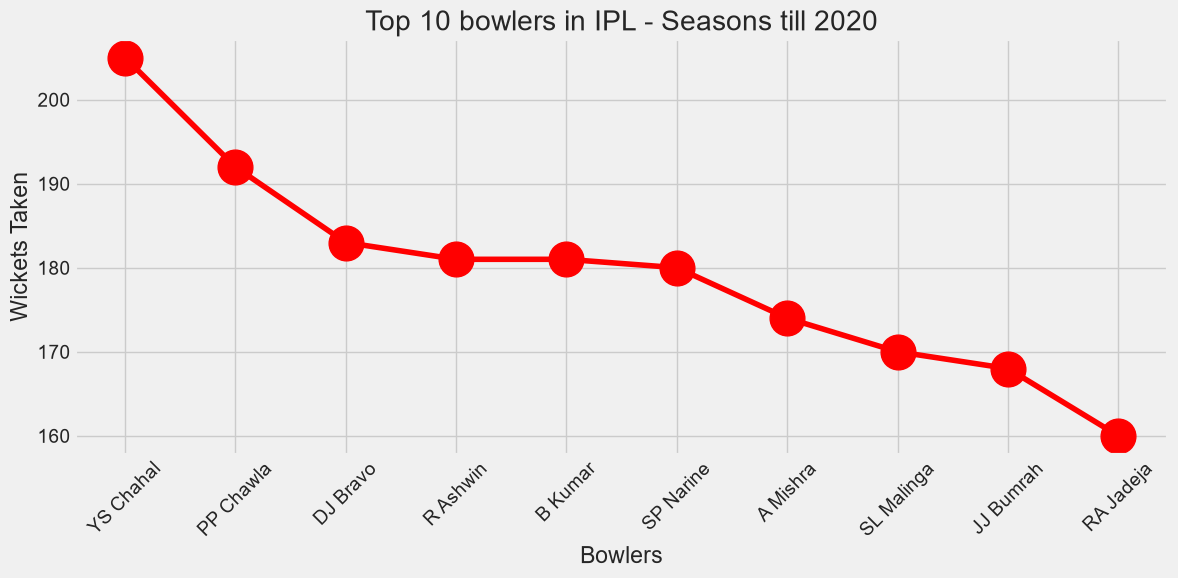

In [28]:
bowling_wickets = deliveries[deliveries['dismissal_kind'] != 'run out']
top_bowlers = bowling_wickets.groupby('bowler')['dismissal_kind'].count().reset_index(
    name='Wickets').sort_values(by='Wickets',ascending=False)[:10]

plt.figure(figsize=(12,6))
plt.plot(top_bowlers['bowler'],top_bowlers['Wickets'], marker= 'o',color='red',ms=25)
plt.title('Top 10 bowlers in IPL - Seasons till 2020')
plt.xlabel('Bowlers')
plt.ylabel('Wickets Taken')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

###### Top 10 Bowling Performances till 2020

In [29]:
match_bowling_top = bowling_wickets.groupby(['match_id','bowler'])['dismissal_kind'].count().reset_index(
    name='Wickets').sort_values(by='Wickets',ascending=False)[:10]

In [30]:
match_bowler_runs = deliveries.groupby(['match_id','bowler'])['total_runs'].sum().reset_index(name='Runs Conceded')

In [31]:
match_bowler_performance = pd.merge(match_bowler_runs,match_bowling_top,how='inner', on =['match_id','bowler'])

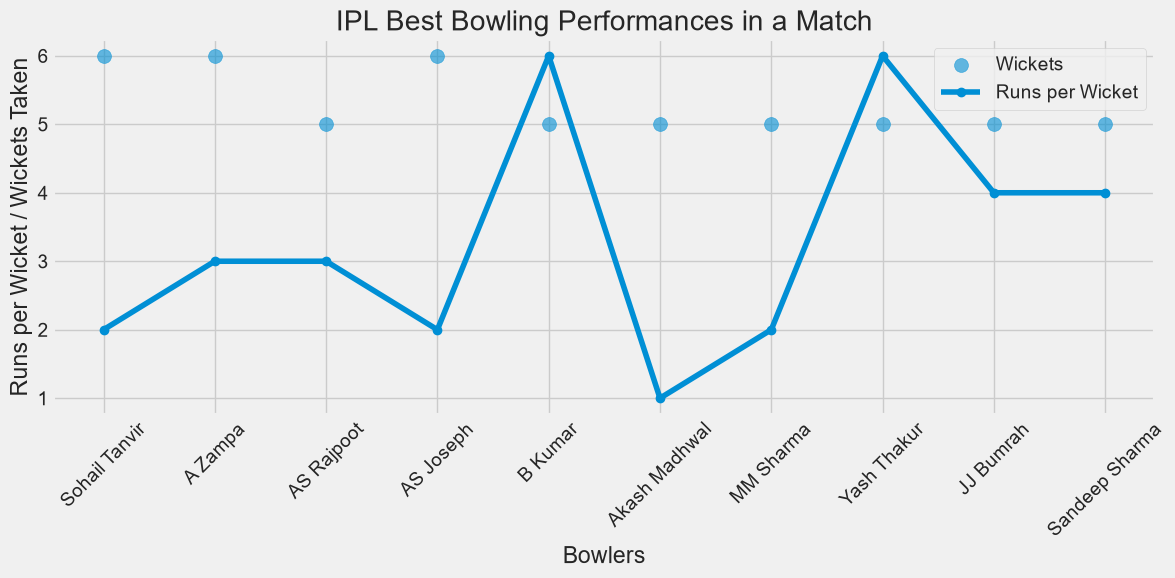

In [32]:
match_bowler_performance['Runs per Wicket'] = np.round(match_bowler_performance['Runs Conceded']/match_bowler_performance['Wickets'],0)


plt.figure(figsize=(12,6))
plt.scatter(match_bowler_performance['bowler'],match_bowler_performance['Wickets'],label='Wickets',s=100,alpha=0.6)
plt.plot(match_bowler_performance['bowler'],match_bowler_performance['Runs per Wicket'],marker='o',label='Runs per Wicket')
plt.title('IPL Best Bowling Performances in a Match')
plt.xlabel('Bowlers')
plt.ylabel('Runs per Wicket / Wickets Taken')
plt.legend()
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

###### Top 10 Cities by Number of Matches

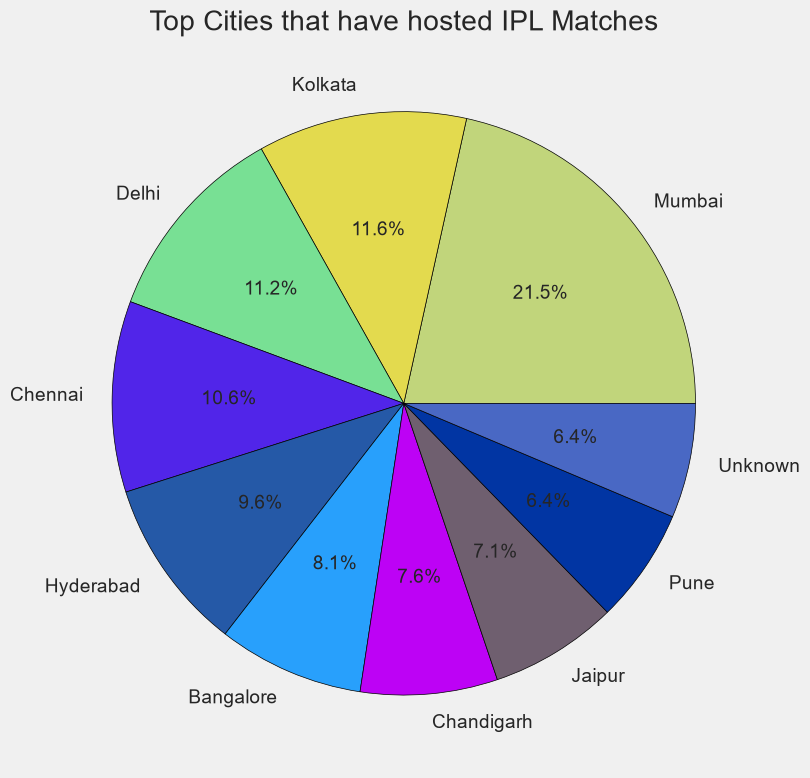

In [33]:
top_cities = matches['city'].value_counts().reset_index(name='Match Count')[:10]

plt.figure(figsize=(8,8))
plt.pie(top_cities['Match Count'], labels = top_cities['city'],colors=random_colors(10),
       autopct='%1.1f%%', wedgeprops=dict(edgecolor='black'))
plt.title('Top Cities that have hosted IPL Matches')
plt.tight_layout()
plt.show()

C:\Users\SACHIN\AppData\Local\Temp\ipykernel_31020\363838552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dismissal_kind',data=deliveries,palette=random_colors(len(deliveries['dismissal_kind'].value_counts())))


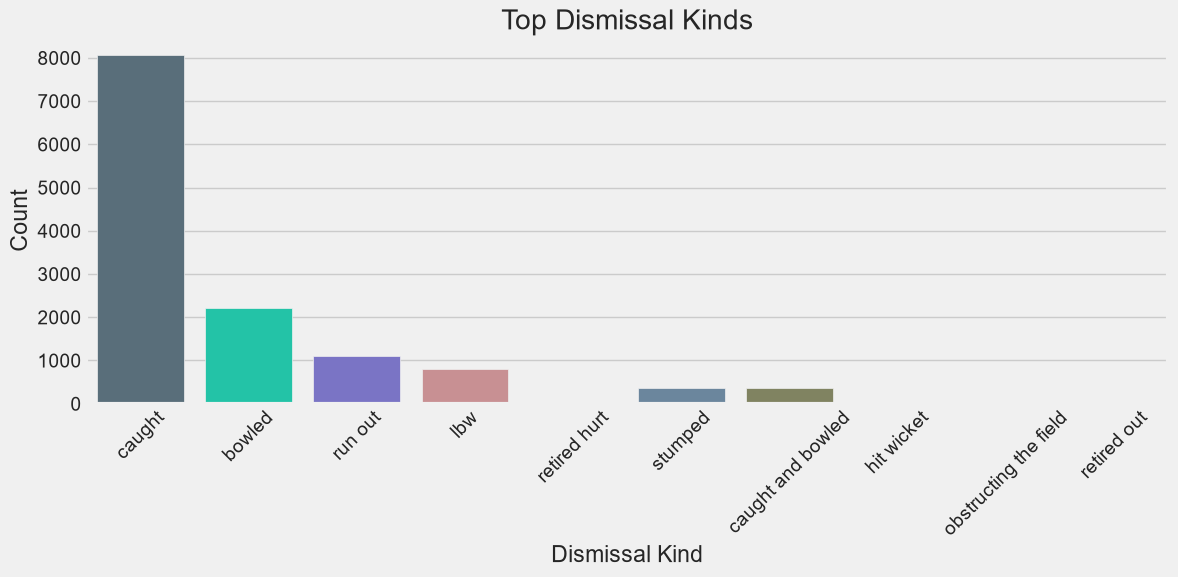

In [34]:
plt.figure(figsize=(12,6))
sns.countplot(x='dismissal_kind',data=deliveries,palette=random_colors(len(deliveries['dismissal_kind'].value_counts())))
plt.title('Top Dismissal Kinds')
plt.xlabel('Dismissal Kind')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

###### Top 10 Best Fielders

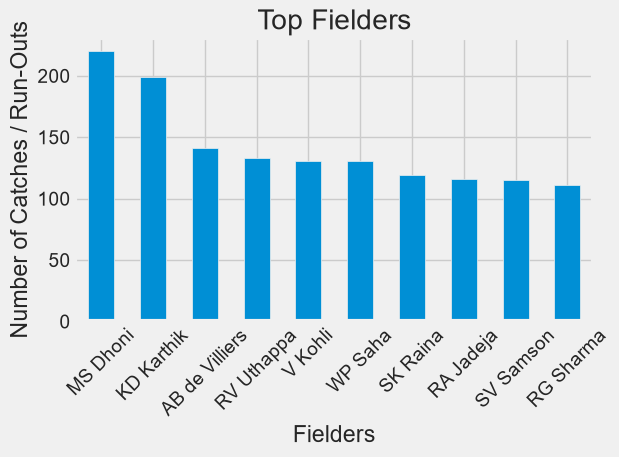

In [35]:
deliveries['fielder'].value_counts()[:10].plot(kind='bar')
plt.title('Top Fielders')
plt.xlabel('Fielders')
plt.ylabel('Number of Catches / Run-Outs')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

###### Analysis Over by Over

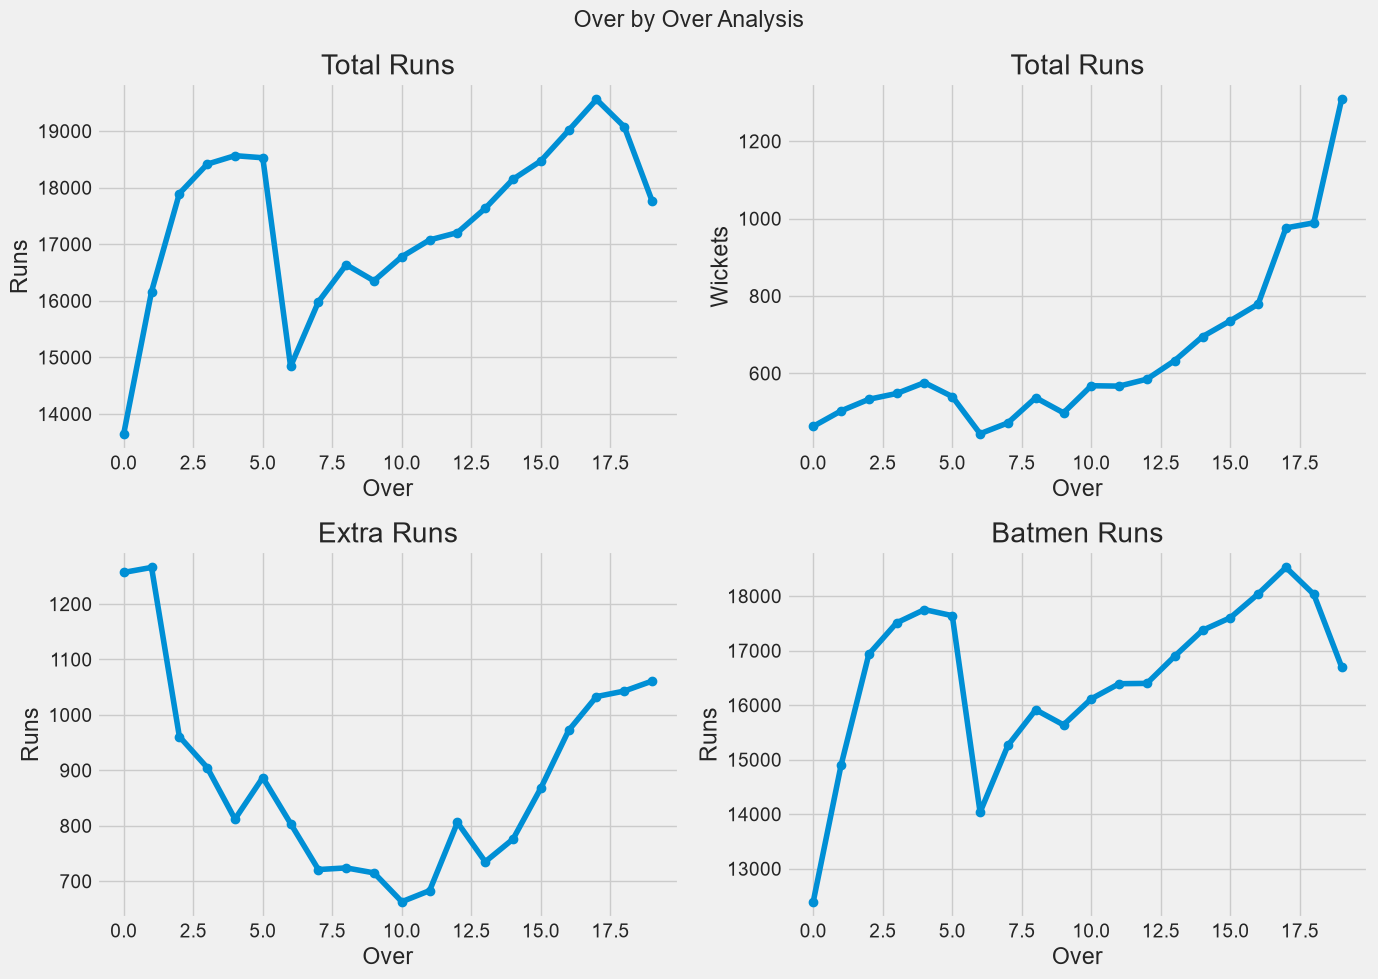

In [36]:
over_summary = deliveries.groupby('over')[['total_runs','is_wicket','extra_runs','batsman_runs']].sum()

fig, axes = plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Over by Over Analysis')


axes[0,0].plot(over_summary.index,over_summary['total_runs'],marker='o')
axes[0,0].set_title('Total Runs')
axes[0,0].set_xlabel('Over')
axes[0,0].set_ylabel('Runs')

axes[0,1].plot(over_summary.index,over_summary['is_wicket'],marker='o')
axes[0,1].set_title('Total Runs')
axes[0,1].set_xlabel('Over')
axes[0,1].set_ylabel('Wickets')

axes[1,0].plot(over_summary.index,over_summary['extra_runs'],marker='o')
axes[1,0].set_title('Extra Runs')
axes[1,0].set_xlabel('Over')
axes[1,0].set_ylabel('Runs')

axes[1,1].plot(over_summary.index,over_summary['batsman_runs'],marker='o')
axes[1,1].set_title('Batmen Runs')
axes[1,1].set_xlabel('Over')
axes[1,1].set_ylabel('Runs')

plt.tight_layout()
plt.show()

###### Toss Decision

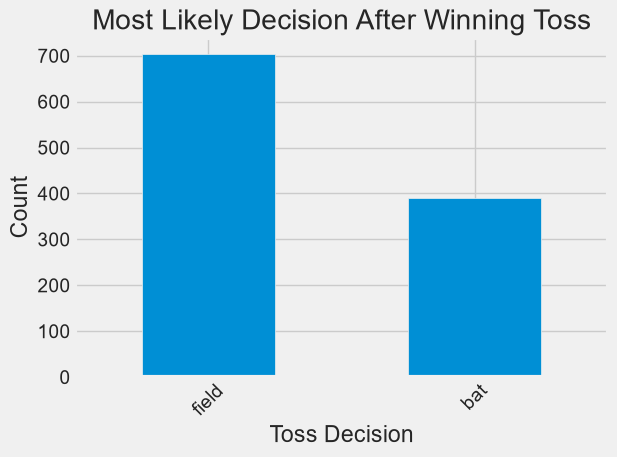

In [37]:
matches['toss_decision'].value_counts().plot(kind='bar')
plt.title('Most Likely Decision After Winning Toss')
plt.xlabel('Toss Decision')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()